In [1]:
import corner
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# import fbu
physical_devices = tf.config.list_physical_devices('GPU') 
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)
from methods import IBU, NPU, MADE

import tensorflow_probability as tfp

tfd = tfp.distributions
tfpl = tfp.layers
tfk = tf.keras
tfkl = tf.keras.layers
tfb = tfp.bijectors

/global/homes/j/jing/.local/perlmutter/tensorflow2.9.0/lib/python3.9/site-packages/corner/core.py:20: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.22.0)
  from scipy.ndimage import gaussian_filter


In [15]:
def MLE(model,ymes,ndim):
    x = tf.Variable(ndim*[1.0/ndim])
    loss = lambda: -model.log_prob(x, bijector_kwargs={'conditional_input': ymes})
    losses = tfp.math.minimize(loss,
                               num_steps=10000,
                               #convergence_criterion=(
                               #     tfp.optimizers.convergence_criteria.LossNotDecreasing(atol=0.001)),
                               trainable_variables=[x],
                               optimizer=tf.optimizers.Adam(learning_rate=0.001))
    return x

def MADE(data_shape, cond_shape):
    # Density estimation with MADE.
    made = tfb.AutoregressiveNetwork(params=2,
                                     hidden_units=[50,50,50], #To be changed when using bigger histograms
                                     event_shape=data_shape,
                                     activation='swish',
                                     conditional=True,
                                     conditional_event_shape=cond_shape,
                                    )
    distribution = tfd.TransformedDistribution(
        distribution=tfd.Sample(tfd.Normal(loc=0., scale=1.), sample_shape=[data_shape]),
        bijector=tfb.MaskedAutoregressiveFlow(made))

    # Construct and fit model.
    x_ = tfkl.Input(shape=(data_shape,), dtype=tf.float32)
    c_ = tfkl.Input(shape=(cond_shape,), dtype=tf.float32)
    log_prob_ = distribution.log_prob(x_, bijector_kwargs={'conditional_input': c_})
    model = tfk.Model([x_,c_], log_prob_)

    model.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4),loss=lambda _, log_prob: -log_prob)
    return model, distribution

def NPU(ymes,Rin,N):
    #Inputs: 
    # ymes: Measured data provided in a histogram with M bins (M,)
    # Rin: Detector resolution matrix. First coordinate is the measured value and second coordinate is the truth level. (M,M)
    # N: Total number of observations
    #Returns samples from p(true|measured).  Would normally want the mode over true, which is equivalent to the MLE given p(true) is uniform.

    M = 1000000 # a big number - should make bigger later
    
#     ts = np.random.dirichlet(np.ones(len(ymes)),size=M)*N
    ts = np.random.uniform(0,1,(M,len(ymes))) #M values with B bins
    ts=ts/np.sum(ts,-1,keepdims=True)*N

    ms = []
    for j in range(len(ts)):
        if j % 100000 == 0: print(f"{j}/{len(ts)}")
        m_hold = [np.random.poisson(ts[j][i]) for i in range(len(ts[j]))] #stat fluctuations
        m_holds = np.random.multinomial(m_hold[0],Rin[:,0])
        for i in range(1, len(ts[j])):
            m_holds += np.random.multinomial(m_hold[i],Rin[:,i])
        ms += [m_holds]
        pass
    ts = np.array(ts)
    ms = np.array(ms)

    n = len(ts)
    x = ms #conditional feature
    y = ts #learn p(y|x)
    nx = N
    ny = N

    #Normalize the total number of events to make the NF easier to train
    x = x/float(nx)
    y = y/float(ny)

    model,dist = MADE(y.shape[1],x.shape[1])
    # Fit.
    batch_size = 10000
    myhistory = model.fit([y,x],
                          y=np.zeros((len(x),0), dtype=np.float32), #dummy labels
                          batch_size=batch_size,
                          epochs=1500,
                          verbose = 1)

    plt.plot(myhistory.history['loss'][10:-1])
    plt.xlabel("epochs")
    plt.ylabel("loss")

    #mle = MLE(dist,ymes/float(nx),y.shape[-1])
    #print(mle)
    nsample = 1000
    mle = MLE(dist,ymes/float(nx),y.shape[-1]).numpy()
    output = dist.sample(nsample, bijector_kwargs={'conditional_input': np.tile(ymes/float(nx),nsample).reshape([nsample,len(ymes)])}).numpy()
    return output*ny,mle*ny


def IBU(data, init, r, det_binwidth=1, mc_binwidth=1, it=10):
    
    # initialize the truth distribution to the prior
    phis = [init]
    
    # iterate the procedure
    for i in range(it):
        
        # update the estimate for the matrix m
        m = r * phis[-1]
        m /= (m.sum(axis=1)[:,np.newaxis] + 10**-50)

        # update the estimate for the truth distribution
        # the factors of binwidth show up here to change probabilities into probability densities
        phis.append(np.dot(m.T, data)*det_binwidth/mc_binwidth)
        
    return phis

In [16]:
# Generate data for W0 training (as well as theta)

bins = np.linspace(-5,5,11)
# bins = [-np.inf, -4, -3, -2, -1, 0, 1, 2, 3, 4, np.inf]
nbins = len(bins)-1

Ndata = 1000000
Nsim = 10000000

mu_sim = 0
sigma_sim = 1
beta_sim = 0
epsilon_sim = 0

mu_data = 0
sigma_data = 1
beta_data = 0
epsilon_data = 0

p = np.array([1./nbins for i in range(1, nbins+1)])

# simulation
T_sim = np.random.normal(mu_sim,sigma_sim,Nsim)
R = []
for i in range(1,nbins+1):
    T_sim_i = T_sim[np.digitize(T_sim, bins)==i]
    R_sim_i = np.random.normal(T_sim_i+beta_sim,epsilon_sim)
    ms = np.array([(np.digitize(R_sim_i, bins)==i).sum()/len(T_sim_i) for i in range(1, nbins+1)])
    ms /= ms.sum() # should we normalize the total probablitiy to 1?
    R.append(ms)
R = np.transpose(np.array(R))

# data
T_data = np.random.normal(mu_data,sigma_data,Ndata).reshape(-1, 1)
R_data = np.random.normal(T_data+beta_data,epsilon_data)

t = np.array([(np.digitize(T_data, bins)==i).sum() for i in range(1, nbins+1)])
m = np.array([(np.digitize(R_data, bins)==i).sum() for i in range(1, nbins+1)])

In [24]:
# np.savez_compressed("test_gaussian_10000000.npz", **{"bins": bins, "m": m, "t": t, "ibu": ibu, "R": R})

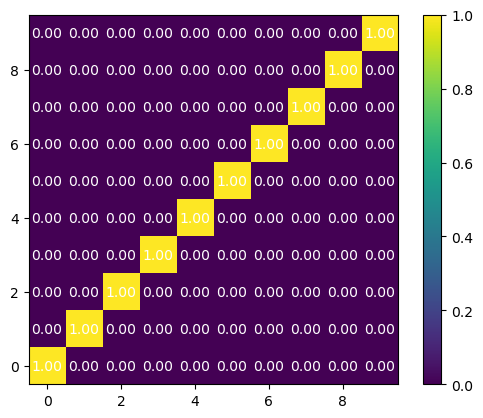

In [17]:
plt.imshow(R,origin='lower')
plt.colorbar()

for i in range(len(R)):
    for j in range(len(R)):
        text = plt.text(j, i, f"{R[i, j]:.2f}", ha="center", va="center", color="w")
        
plt.savefig('gaus_resp.pdf',bbox_inches='tight')

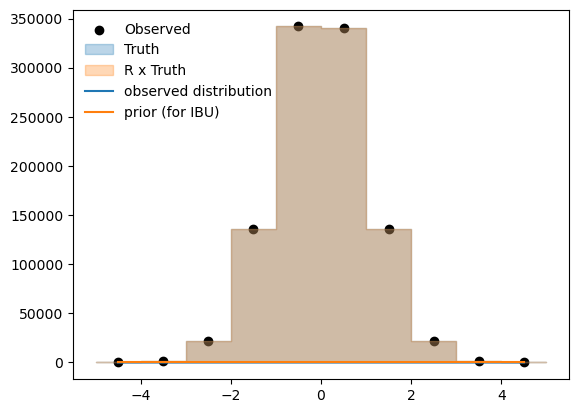

In [18]:
plt.scatter(0.5*(bins[1:]+bins[:-1]), m, color='black', label='Observed')
plt.fill_between(bins, np.insert(t, len(t), np.array(t[-1])), step='post', alpha=0.3, color='tab:blue', label='Truth')
plt.fill_between(bins, np.insert(np.matmul(R, t), len(np.matmul(R, t)), np.array(np.matmul(R, t)[-1])), step='post', alpha=0.3, color='tab:orange', label='R x Truth')
plt.legend(frameon=False, loc="upper left")
plt.savefig('gaus_init.pdf',bbox_inches='tight')

plt.plot(0.5*(bins[1:]+bins[:-1]), t/t.sum(), label='observed distribution')
plt.plot(0.5*(bins[1:]+bins[:-1]), p, label='prior (for IBU)')
plt.legend(frameon=False, loc="upper left")
plt.show()

In [4]:
N = m.sum()
print(N)

npu,mle = NPU(m,R,N)

In [46]:
it = 10

ibu = IBU(m, p, R, 1, 1, it)[it]
print(ibu)

[2.90000e+01 1.30100e+03 2.14050e+04 1.36131e+05 3.42101e+05 3.40616e+05
 1.35768e+05 2.13100e+04 1.30000e+03 3.80000e+01]


In [47]:
np.savez_compressed("npu_gaussian_1000000_resp1.npz", **{"bins": bins, "m": m, "t": t, "ibu": ibu, "npu": npu, "mle": mle, "R": R})

In [19]:
# fbu_ins = fbu.PyFBU()

In [ ]:
# reg = fbu.Regularization(regname='Tikhonov', parameters=[10,1])

In [ ]:
# fbu_ins.data = m
# fbu_ins.response = R
# fbu_ins.lower = list(np.zeros(nbins))
# fbu_ins.upper = list(400000 * np.ones(nbins))
# fbu_ins.regularization = reg

In [ ]:
# fbu_ins.run()

In [ ]:
# trace = fbu_ins.trace
# print(trace)
# Each array corresponds to the projection of the posterior distribution for a given bin.

# plt.hist(trace[1], bins=50, alpha=0.85, density=False)
# plt.show()

In [ ]:
# from scipy.stats import mode

# fbu_result_mean = []
# fbu_result_mode = []
# fbu_sigma = []
# for i in range(nbins):
#     fbu_result_mode.append(mode(trace[i],axis=0)[0])
#     fbu_result_mean.append(np.mean(trace[i]))
#     fbu_sigma.append(np.std(trace[i]))
# fbu_result_mode = np.squeeze(fbu_result_mode)
# print(np.squeeze(fbu_result_mode), fbu_sigma)

In [20]:
aaa=np.load("npu_gaussian_1000000_resp1.npz")
# fbu=np.load("fbu_gaussian_1000000.npz")
list(aaa.keys())

['bins', 'm', 't', 'ibu', 'npu', 'mle', 'R']

In [35]:
npu = aaa['npu']
ibu = aaa['ibu']
bins = aaa['bins']
mle = aaa['mle']
t = aaa['t']
# fbu_mean = np.stack(fbu['mean']).mean(axis=0)
# fbu_std = np.stack(fbu['std']).std(axis=0)

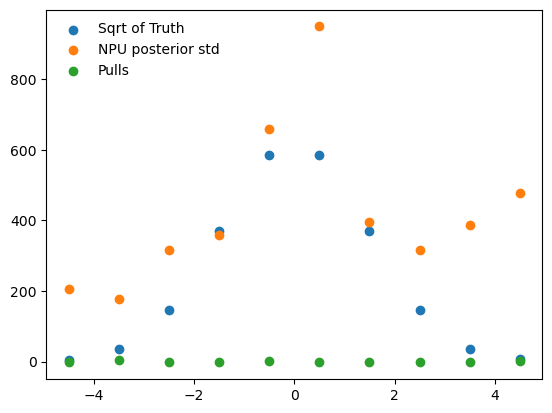

In [24]:
# plt.scatter(0.5*(bins[1:]+bins[:-1]), np.sqrt(t), color='tab:blue', label='Sqrt of Truth')
# plt.scatter(0.5*(bins[1:]+bins[:-1]), npu.std(axis=0), color='tab:orange', label='NPU posterior std')
# plt.scatter(0.5*(bins[1:]+bins[:-1]), np.divide((npu.mean(axis=0)-t), npu.std(axis=0)), color='tab:green', label='Pulls')
# plt.legend(frameon=False, loc="upper left")

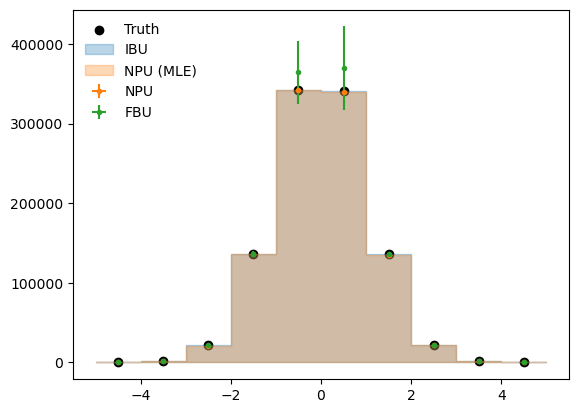

In [8]:
# plt.scatter(list(0.5*(bins[1:]+bins[:-1]))*1000,npu.reshape(-1), marker='*', label="NPU",s=40)
# train stat = 10000
plt.scatter(0.5*(bins[1:]+bins[:-1]), t, color='black', label='Truth')
plt.fill_between(bins, np.insert(ibu, len(ibu), np.array(ibu[-1])), step='post', alpha=0.3, color='tab:blue', label='IBU')
plt.fill_between(bins, np.insert(mle, len(mle), np.array(mle[-1])), step='post', alpha=0.3, color='tab:orange', label='NPU (MLE)')
plt.errorbar(0.5*(bins[1:]+bins[:-1]), npu.mean(axis=0), xerr=0, yerr=npu.std(axis=0), label='NPU', color='tab:orange', marker='.', linestyle='None')
# plt.errorbar(0.5*(bins[1:]+bins[:-1]), fbu_mean, xerr=0, yerr=fbu_std, label='FBU', color='tab:green', marker='.', linestyle='None')
plt.legend(frameon=False, loc="upper left")
plt.savefig('gaussian.pdf')
plt.show()

Text(0.5, 1.0, 'For NPU')

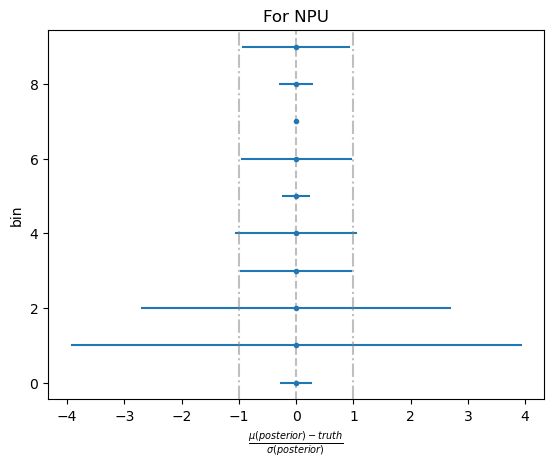

In [34]:
plt.errorbar(x=np.zeros(10), y=np.arange(10), xerr=np.abs(np.divide((npu.mean(axis=0)-t) , npu.std(axis=0))), fmt=".");
plt.axvline(ymin=0, ymax=10, linestyle="--", color="gray", alpha=0.5);
plt.axvline(x=1, ymin=0, ymax=10, linestyle="-.", color="gray", alpha=0.5);
plt.axvline(x=-1, ymin=0, ymax=10, linestyle="-.", color="gray", alpha=0.5);
plt.xlabel(r"$\frac{\mu(posterior) - truth}{\sigma(posterior)}$");
plt.ylabel(r"bin");
plt.title(f"For NPU")

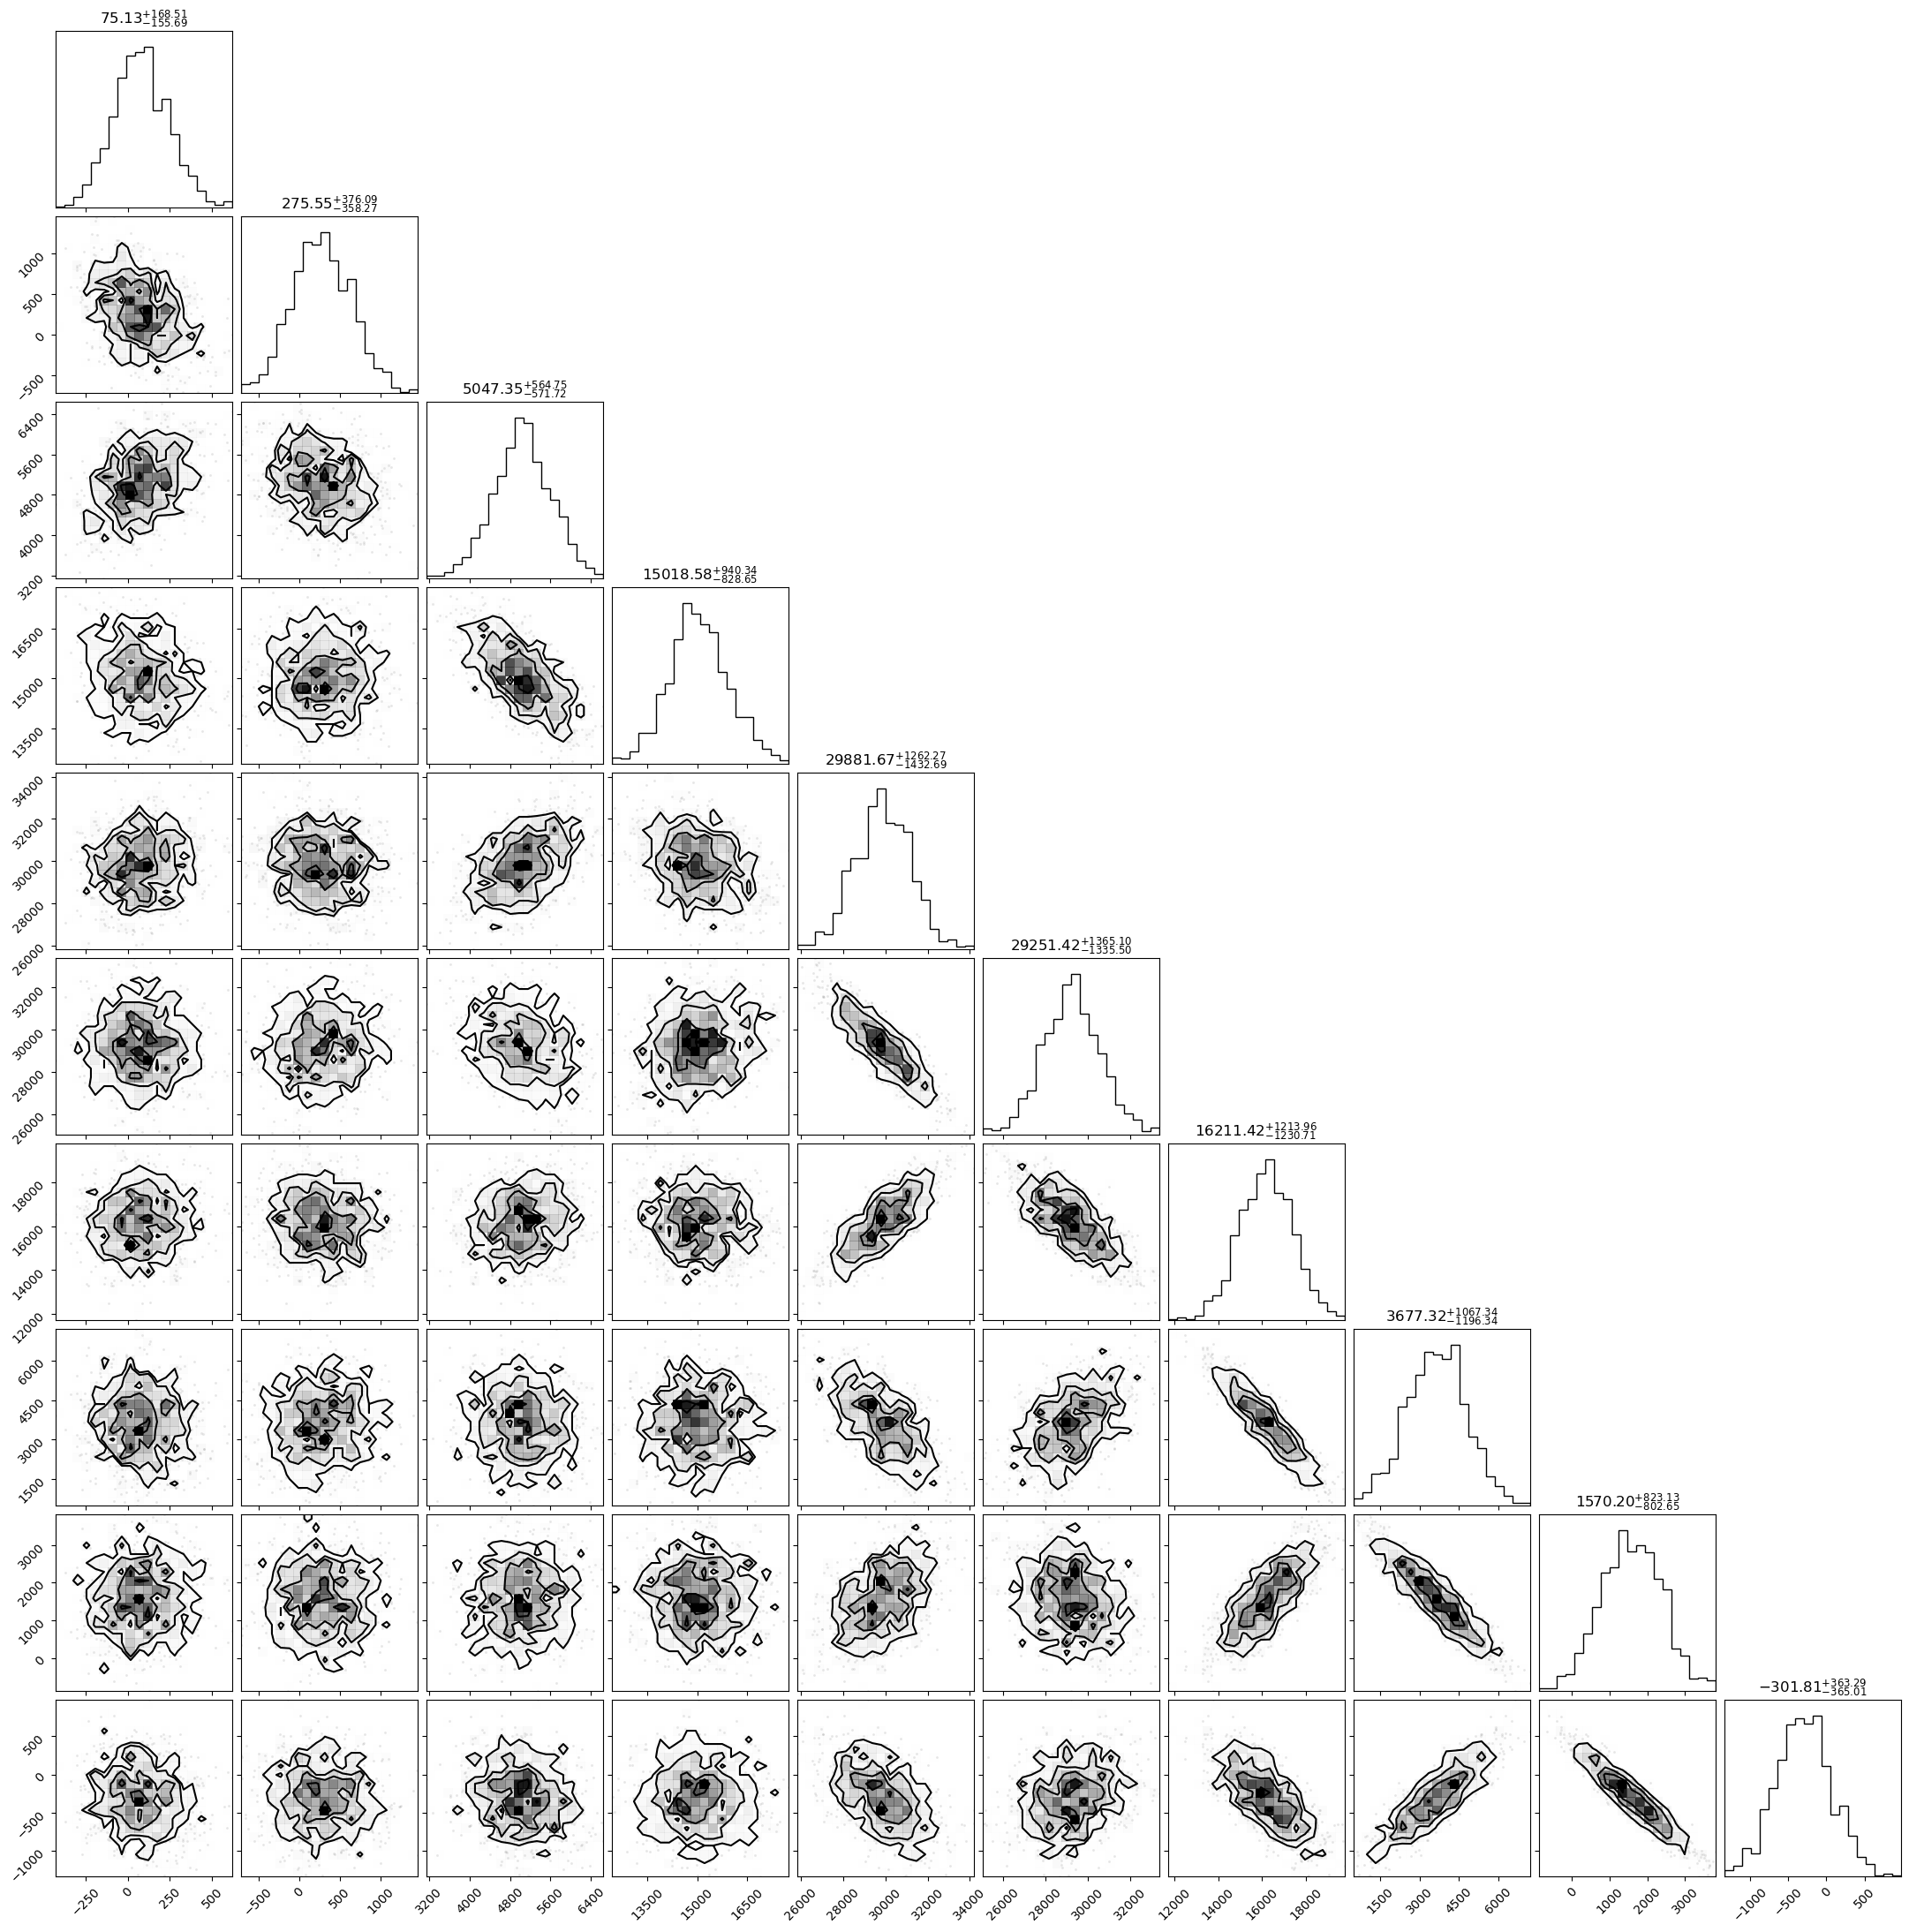

In [37]:
figure = corner.corner(
    npu,
#     labels=[
#         r"Bin Index",
#         r"Bin Index",
#         r"$\log \alpha$",
#         r"$\Gamma \, [\mathrm{parsec}]$",
#     ],
#     quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
)

figure.savefig('gaus_corner.pdf')